In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [12]:
# --- 1. LOAD THE DATA ---
print("Downloading MNIST (this may take a minute)...")
# as_frame=False ensures we get clean numpy arrays instead of pandas tables
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]


In [3]:
# The answers (y) download as text (e.g., '5'). Convert them to actual numbers.
y = y.astype(np.uint8)

# --- 2. SPLIT THE DATA ---
# Standard MNIST rules: First 60,000 for training and last 10,000 for testing.
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [4]:
# --- 3. BUILD AND TRAIN THE MODEL ---
print("Training the Random Forest Model...")
# n_estimators=100 means we are hiring 100 "Decision Trees" to vote on the answer.
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(X_train, y_train)

Training the Random Forest Model...


RandomForestClassifier(random_state=42)

In [9]:
# --- 4. TEST THE MODEL ---
print("Time for Prediction...")
predictions = forest_clf.predict(X_test)
predictions[:10] # Show the first 10 predictions to check if they look reasonable.
actual_nums = y_test[:10]
print(f"Predicted: {predictions[:10]}")
print(f"Actual:    {actual_nums}")

Time for Prediction...
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


In [ ]:
# Calculate and print the grade!
accuracy = accuracy_score(y_test, predictions)
print(f"Final Accuracy: {accuracy * 100:.2f}% !!!\n")

Final Accuracy: 97.05% !!!



Building the 10x5 Gallery based on the Model's Predictions...


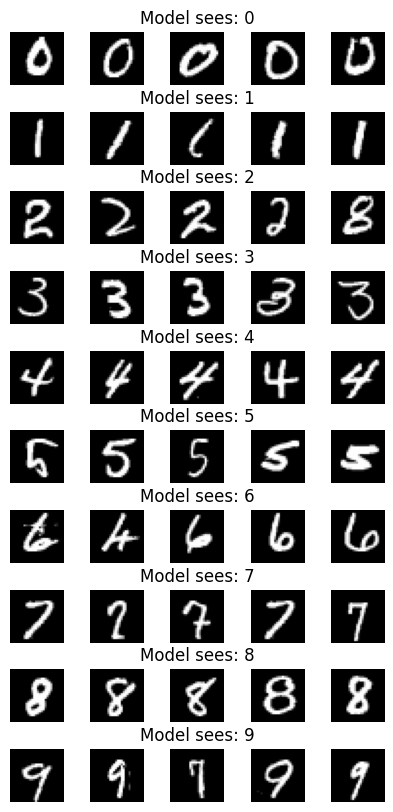

In [7]:
# --- 5. THE 10x5 GALLERY VISUALIZATION ---
def plot_prediction_gallery(X_data, predicted_answers):
    print("Building the 10x5 Gallery based on the Model's Predictions...")
    cols = 5
    num_of_classes = 10
    
    # Buy the poster board
    fig, axs = plt.subplots(nrows=num_of_classes, ncols=cols, figsize=(5, 10))
    fig.subplots_adjust(hspace=0.5) # Add a tiny bit of vertical space for titles
    
    for i in range(cols):
        for j in range(num_of_classes):
            # FILTER: Find only the images the model *predicted* as digit 'j'
            x_selected = X_data[predicted_answers == j]
            
            # Use the clean Pythonic way to grab one random image
            winning_image_flat = random.choice(x_selected)
            
            # Convert the flat 784 array back into a 2D 28x28 grid so human eyes can see it
            winning_image_2d = winning_image_flat.reshape(28, 28)
            
            # Paint the specific cell on the poster board
            axs[j][i].imshow(winning_image_2d, cmap='gray')
            axs[j][i].axis("off")
            
            # Put the title in the middle column
            if i == 2:
                axs[j][i].set_title(f"Model sees: {j}")

    plt.show()

# Run our custom function using the Test Images and the Model's Predictions!
plot_prediction_gallery(X_test, predictions)